In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px

In [ ]:
df = pd.read_csv("/content/quick_commerce_data_raw.csv")

In [ ]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [ ]:
#Dataset Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  object 
 2   City                     948000 non-null   object 
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  object 
 9   Payment_Method           1000000 non-null  object 
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), object(4)
memory u

In [ ]:
df.head(5)

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8


In [ ]:
df['Company']

,Company
0,Swiggy Instamart
1,Flipkart Minutes
2,Flipkart Minutes
3,Swiggy Instamart
4,Dunzo
...,...
999995,Big Basket
999996,Swiggy Instamart
999997,Jio Mart
999998,Dunzo


In [ ]:
# Statistics summary
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,965000.000000,953000.000000,1000000.000000,895863.000000
mean,1.500000e+06,38.470387,571.643584,16.452412,7.750231,9.998317,3.042072,0.400883,3.749257
std,2.886753e+05,12.118520,382.784520,6.257172,4.186665,5.478725,1.186872,0.490078,0.722121
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.250001e+06,28.000000,287.840150,12.368000,4.130000,5.000000,2.000000,0.000000,3.100000
50%,1.500000e+06,38.000000,531.324600,16.342000,7.740000,10.000000,3.000000,0.000000,3.700000
75%,1.750000e+06,49.000000,796.182500,20.196000,11.380000,15.000000,4.000000,1.000000,4.400000
max,2.000000e+06,59.000000,13877.325000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [ ]:
#Checking Missing Values
df.isna().sum()

,0
Order_ID,0
Company,0
City,52000
Customer_Age,0
Order_Value,0
Delivery_Time_Min,0
Distance_Km,0
Items_Count,35000
Product_Category,0
Payment_Method,0


In [ ]:
#Checking in each row if any missing values
df[df.isna().any(axis=1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
6,1000007,Blinkit,Bengluru,37,516.86480,18.476,12.46,19.0,Snacks,Debit Card,2.8,0,NaN
17,1000018,Zepto,Delhi,23,1041.42975,5.000,14.74,18.0,Snacks,Wallet,NaN,1,NaN
21,1000022,Blinkit,NaN,41,716.89860,17.804,11.34,7.0,Beverages,Credit Card,2.7,1,3.6
22,1000023,Jio Mart,Delhi,48,50.00000,8.498,0.83,3.0,Snacks,Cash on Delivery,3.1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999966,1999967,Dunzo,NaN,39,783.89250,18.820,14.70,NaN,Household,Wallet,3.1,1,4.9
999975,1999976,Amazon Now,Bengluru,34,515.89380,21.294,10.49,10.0,Fruits & Vegetables,Wallet,NaN,1,3.0
999981,1999982,Amazon Now,NaN,33,939.34470,21.080,11.80,18.0,Dairy,Wallet,3.2,1,4.4
999983,1999984,Swiggy Instamart,Hyderabad,42,50.00000,13.386,2.31,2.0,Groceries,Wallet,NaN,0,3.2


In [ ]:
#Dropping all missing values in city column
df.dropna(subset=['City'],inplace=True)

In [ ]:
df.shape

(948000, 13)

In [ ]:
df['Items_Count'] = pd.to_numeric(df['Items_Count'], errors='coerce')
df['Items_Count'] = df['Items_Count'].fillna(df['Items_Count'].mode()[0])

In [ ]:
df.shape

(948000, 13)

In [ ]:
df.isna().sum()

,0
Order_ID,0
Company,0
City,0
Customer_Age,0
Order_Value,0
Delivery_Time_Min,0
Distance_Km,0
Items_Count,0
Product_Category,0
Payment_Method,0


In [ ]:
#Filling missing values of Customer_Rating column
df['Customer_Rating'] = df.groupby('Company')['Customer_Rating'].transform(lambda x: x.fillna(x.mean()))

In [ ]:
df.isna().sum()

,0
Order_ID,0
Company,0
City,0
Customer_Age,0
Order_Value,0
Delivery_Time_Min,0
Distance_Km,0
Items_Count,0
Product_Category,0
Payment_Method,0


In [ ]:
#Filling missing values of Delivery_Partner_Rating
df['Delivery_Partner_Rating'] = df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].transform(lambda x: x.fillna(x.mean()))

In [ ]:
df.isna().sum()

,0
Order_ID,0
Company,0
City,0
Customer_Age,0
Order_Value,0
Delivery_Time_Min,0
Distance_Km,0
Items_Count,0
Product_Category,0
Payment_Method,0


In [ ]:
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].fillna(df['Delivery_Partner_Rating'].mean())

In [ ]:
df.isna().sum()

,0
Order_ID,0
Company,0
City,0
Customer_Age,0
Order_Value,0
Delivery_Time_Min,0
Distance_Km,0
Items_Count,0
Product_Category,0
Payment_Method,0


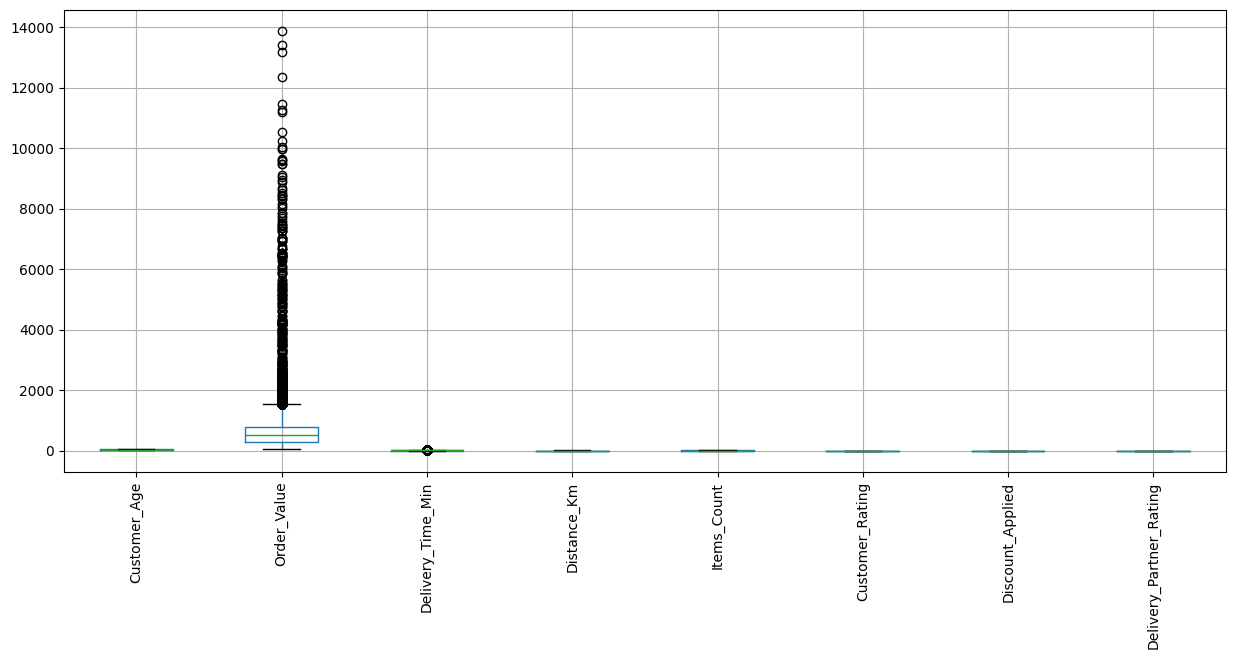

In [ ]:
#Checking for outliers
plt.figure(figsize=(15,6))
df.drop(columns=['Order_ID']).boxplot()
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Capping Mathod --> df['Order_Value'] = df['Order_Value'].clip(upper=2500)

In [ ]:
df.shape

(948000, 13)

In [ ]:
#Filtering
df[df['Order_Value'] <= 2500]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,19.0,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 948000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 948000 non-null  int64  
 1   Company                  948000 non-null  object 
 2   City                     948000 non-null  object 
 3   Customer_Age             948000 non-null  int64  
 4   Order_Value              948000 non-null  float64
 5   Delivery_Time_Min        948000 non-null  float64
 6   Distance_Km              948000 non-null  float64
 7   Items_Count              948000 non-null  float64
 8   Product_Category         948000 non-null  object 
 9   Payment_Method           948000 non-null  object 
 10  Customer_Rating          948000 non-null  float64
 11  Discount_Applied         948000 non-null  int64  
 12  Delivery_Partner_Rating  948000 non-null  float64
dtypes: float64(6), int64(3), object(4)
memory usage: 101.3+ MB


In [ ]:
df.isna().sum()

,0
Order_ID,0
Company,0
City,0
Customer_Age,0
Order_Value,0
Delivery_Time_Min,0
Distance_Km,0
Items_Count,0
Product_Category,0
Payment_Method,0


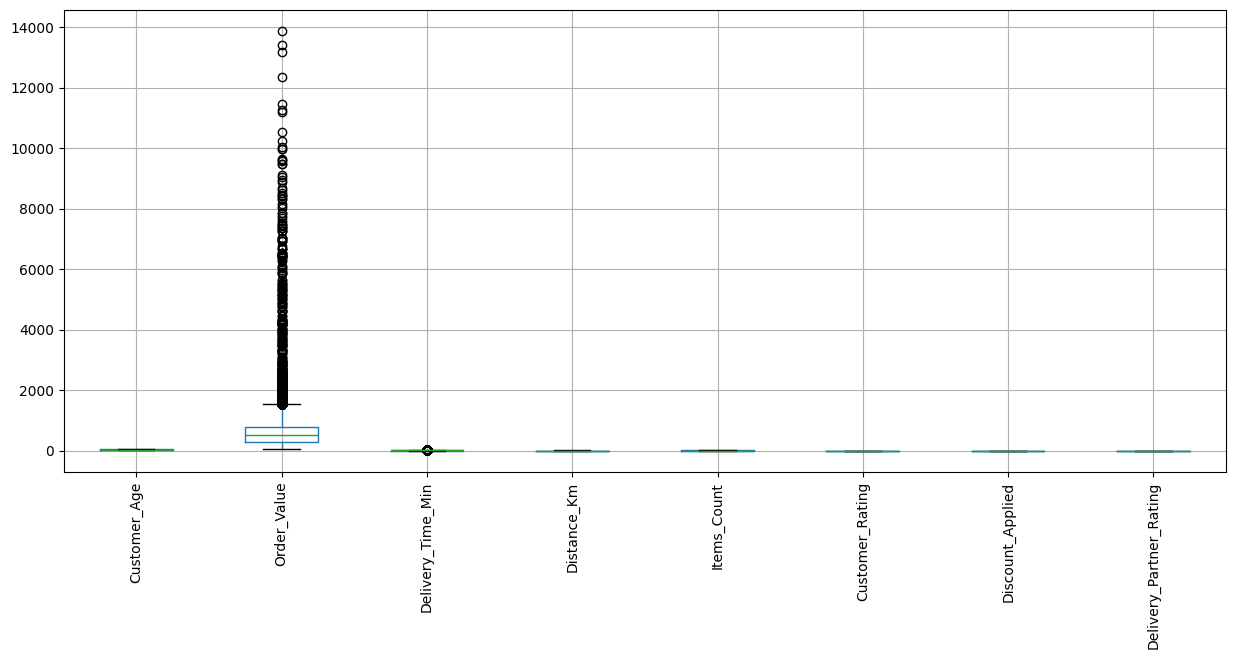

In [ ]:
plt.figure(figsize=(15,6))
df.drop(columns=['Order_ID']).boxplot()
plt.xticks(rotation=90)
plt.show()

In [ ]:
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,9.480000e+05,948000.000000,948000.000000,948000.000000,948000.000000,948000.000000,948000.000000,948000.000000,948000.000000
mean,1.500024e+06,38.471327,572.076108,16.501932,7.750000,10.313334,3.042883,0.400826,3.749178
std,2.887244e+05,12.118978,383.011569,6.330006,4.187026,5.630804,1.161115,0.490066,0.684364
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.249946e+06,28.000000,287.992575,12.362000,4.130000,5.000000,2.100000,0.000000,3.200000
50%,1.500026e+06,38.000000,531.786950,16.384000,7.750000,10.000000,3.015637,0.000000,3.753051
75%,1.750130e+06,49.000000,796.844125,20.302000,11.380000,15.000000,4.000000,1.000000,4.300000
max,2.000000e+06,59.000000,13877.325000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 948000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 948000 non-null  int64  
 1   Company                  948000 non-null  object 
 2   City                     948000 non-null  object 
 3   Customer_Age             948000 non-null  int64  
 4   Order_Value              948000 non-null  float64
 5   Delivery_Time_Min        948000 non-null  float64
 6   Distance_Km              948000 non-null  float64
 7   Items_Count              948000 non-null  float64
 8   Product_Category         948000 non-null  object 
 9   Payment_Method           948000 non-null  object 
 10  Customer_Rating          948000 non-null  float64
 11  Discount_Applied         948000 non-null  int64  
 12  Delivery_Partner_Rating  948000 non-null  float64
dtypes: float64(6), int64(3), object(4)
memory usage: 101.3+ MB


In [ ]:
#Changing datatype of order_id
df['Order_ID'] = df['Order_ID'].astype(str)

In [ ]:
#Rounding off values of column
df['Order_Value'] = np.round(df['Order_Value'])
df['Delivery_Time_Min'] = np.round(df['Delivery_Time_Min'])
df['Distance_Km'] = np.round(df['Distance_Km'])
df['Customer_Rating'] = np.round(df['Customer_Rating'])
df['Delivery_Partner_Rating']= np.round(df['Delivery_Partner_Rating'])

In [ ]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.0,19.0,12.0,12.0,Dairy,Wallet,2.0,1,3.0
1,1000002,Flipkart Minutes,Amritsar,56,1007.0,20.0,13.0,10.0,Snacks,Cash on Delivery,2.0,0,3.0
2,1000003,Flipkart Minutes,Mumbai,18,1212.0,17.0,5.0,19.0,Personal Care,Cash on Delivery,3.0,0,4.0
3,1000004,Swiggy Instamart,Delhi,23,1179.0,6.0,6.0,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.0,12.0,2.0,13.0,Household,Wallet,4.0,0,5.0


In [ ]:
#Changing the datatype of columns from float --> int
df['Order_Value'] = df['Order_Value'].astype(int)
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].astype(int)
df['Distance_Km'] = df['Distance_Km'].astype(int)
df['Customer_Rating'] = df['Customer_Rating'].astype(int)
df['Delivery_Time_Min']= df['Delivery_Time_Min'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 948000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 948000 non-null  object 
 1   Company                  948000 non-null  object 
 2   City                     948000 non-null  object 
 3   Customer_Age             948000 non-null  int64  
 4   Order_Value              948000 non-null  int64  
 5   Delivery_Time_Min        948000 non-null  int64  
 6   Distance_Km              948000 non-null  int64  
 7   Items_Count              948000 non-null  float64
 8   Product_Category         948000 non-null  object 
 9   Payment_Method           948000 non-null  object 
 10  Customer_Rating          948000 non-null  int64  
 11  Discount_Applied         948000 non-null  int64  
 12  Delivery_Partner_Rating  948000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 101.3+ MB


In [ ]:
#Quick Commerce Platform that has the highest Revenue
company_revenue = df.groupby('Company')['Order_Value'].sum()
company_revenue.sort_values(ascending=False)

,Order_Value
Company,
Swiggy Instamart,76630245
Blinkit,72668361
Zepto,70525710
Big Basket,68075291
Flipkart Minutes,67133357
Amazon Now,65945559
Dunzo,64132514
Jio Mart,57216758


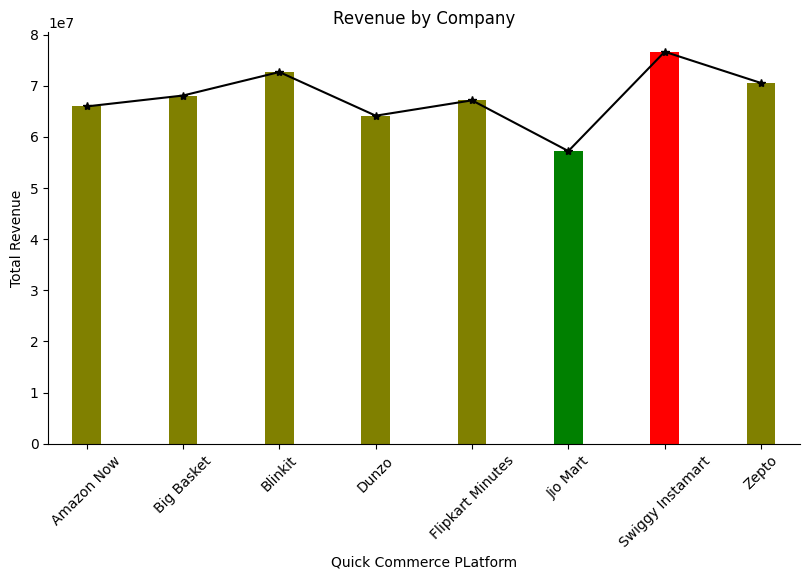

In [ ]:
plt.figure(figsize=(8,5))


max_company = company_revenue.max()
min_company = company_revenue.min()

colors = ['red' if company == max_company else
          'green' if company == min_company else
          'olive'
          for company in company_revenue]

company_revenue.plot(kind='bar', color = colors, width = 0.3)
company_revenue.plot(kind='line', color = 'black', marker='*')

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.xlabel('Quick Commerce PLatform')
plt.ylabel('Total Revenue')
plt.title('Revenue by Company')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Platform that has the highest Average Order Value(AOV)
Average_order_value = df.groupby('Company')['Order_Value'].mean()
Average_order_value.sort_values(ascending=False)

,Order_Value
Company,
Swiggy Instamart,646.532335
Blinkit,611.053884
Zepto,594.656869
Big Basket,576.503739
Flipkart Minutes,564.198010
Amazon Now,558.354365
Dunzo,541.257461
Jio Mart,483.715385


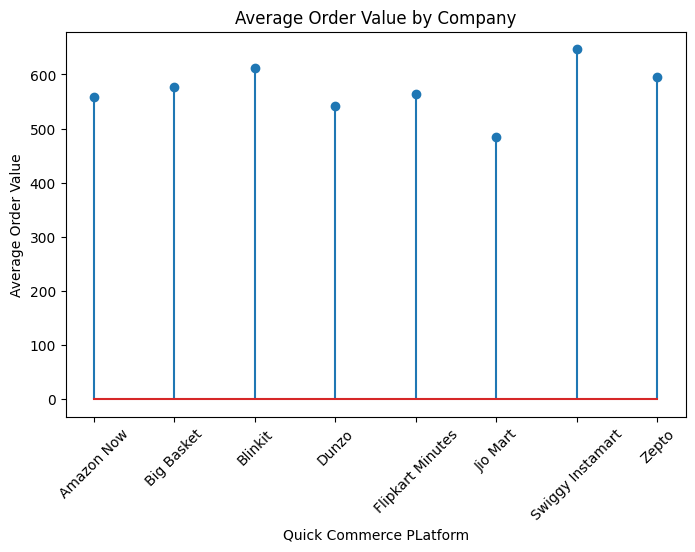

In [ ]:
plt.figure(figsize=(8,5))
plt.stem(Average_order_value.index, Average_order_value.values)

plt.xlabel('Quick Commerce PLatform')
plt.ylabel('Average Order Value')
plt.title('Average Order Value by Company')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Variation of customer rating across platforms
customer_rating = df.groupby('Company')['Customer_Rating'].mean()
customer_rating.sort_values(ascending=False)

,Customer_Rating
Company,
Blinkit,3.580703
Swiggy Instamart,3.279553
Zepto,3.202995
Big Basket,3.097940
Flipkart Minutes,3.016438
Amazon Now,2.913434
Jio Mart,2.819759
Dunzo,2.428035


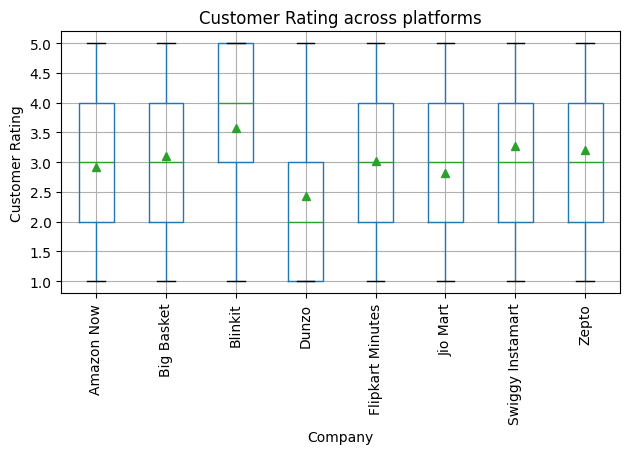

In [ ]:
df.boxplot(column='Customer_Rating', by='Company', showmeans = True)
plt.xticks(rotation=90)
plt.suptitle("")
plt.title('Customer Rating across platforms')
plt.ylabel('Customer Rating')
plt.tight_layout()
plt.show()

In [ ]:
grouped_rating = df.groupby(['Company','Customer_Rating']).size().unstack(fill_value=0)

In [ ]:
grouped_rating

Customer_Rating,1,2,3,4,5
Company,,,,,
Amazon Now,15980,30358,30870,29704,11195
Big Basket,10144,30351,31027,30918,15643
Blinkit,1061,25563,25567,36720,30012
Dunzo,29825,36285,25385,25822,1171
Flipkart Minutes,12550,30789,31232,30991,13427
Jio Mart,18516,30519,31088,30095,8068
Swiggy Instamart,5002,30287,31051,30945,21240
Zepto,7619,29773,31380,30568,19259


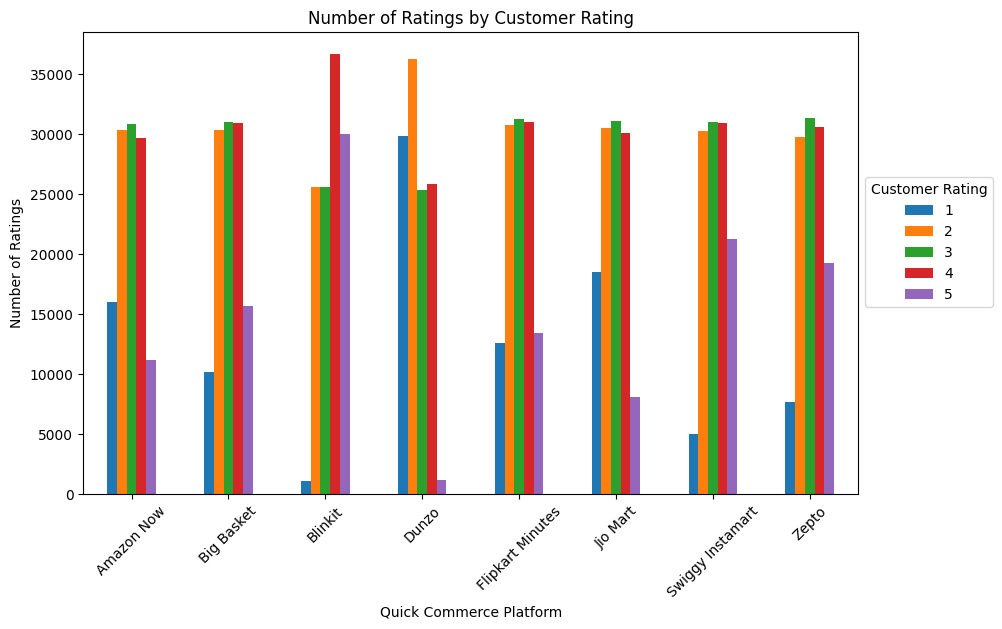

In [ ]:
grouped_rating.plot(kind='bar', figsize=(10,6))
plt.xlabel('Quick Commerce Platform')
plt.ylabel('Number of Ratings')
plt.title('Number of Ratings by Customer Rating')
plt.legend(title='Customer Rating',bbox_to_anchor = (1,0.7), loc = 'upper left')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Finding if delivery time affects the delivery partner ratings
df['Delivery_Partner_Rating'].mean()

np.float64(3.8002943037974686)

In [ ]:
df['Delivery_Time_Min'].mean()

np.float64(16.506478902953585)

In [ ]:
x=df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].mean()
x

,Delivery_Partner_Rating
Delivery_Time_Min,
5,3.804022
6,3.798591
7,3.805865
8,3.803796
9,3.804402
10,3.801602
11,3.799979
12,3.798861
13,3.795765


In [ ]:
df['Delivery_Time_Min'].corr(df['Delivery_Partner_Rating']) #Hence the two columns are not related


np.float64(-0.0027711759347191353)

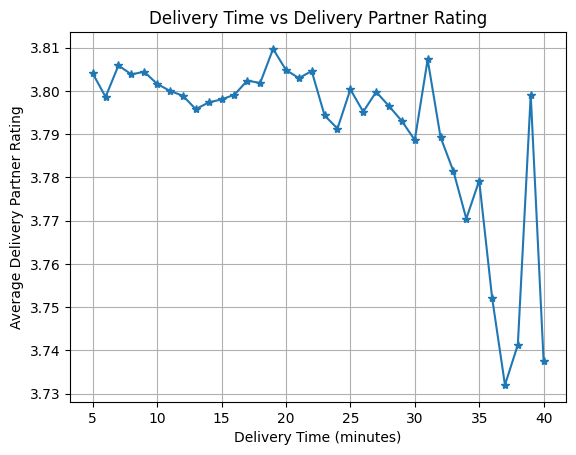

In [ ]:
x.plot(marker = '*')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Average Delivery Partner Rating')
plt.title('Delivery Time vs Delivery Partner Rating')
plt.grid(True)


In [ ]:
df['delivery_time_bucket'] = pd.cut(
                             df['Delivery_Time_Min'],
                             bins=(1, 10, 20, 30, 40, 50),
                             labels=("Very Fast delivery", "Fast Delivery","Normal Delivery", "Slow Delivery", "Very Slow Delivery")
)
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,delivery_time_bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12,12.0,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,13,10.0,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,5,19.0,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6,2.0,Dairy,Credit Card,5,1,5,Very Fast delivery
4,1000005,Dunzo,Mumbai,44,586,12,2,13.0,Household,Wallet,4,0,5,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72,18,3,19.0,Fruits & Vegetables,Wallet,4,0,3,Fast Delivery
999996,1999997,Swiggy Instamart,Mumbai,33,1510,18,11,9.0,Beverages,Debit Card,4,1,4,Fast Delivery
999997,1999998,Jio Mart,Noida,29,637,18,3,6.0,Groceries,Cash on Delivery,3,0,5,Fast Delivery
999998,1999999,Dunzo,Pune,42,1103,13,8,12.0,Snacks,Wallet,4,1,4,Fast Delivery


In [ ]:
bucket_avg = df.groupby('delivery_time_bucket')['Delivery_Partner_Rating'].mean()
bucket_avg

/tmp/ipykernel_2449/1570340286.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_avg = df.groupby('delivery_time_bucket')['Delivery_Partner_Rating'].mean()


,Delivery_Partner_Rating
delivery_time_bucket,
Very Fast delivery,3.803225
Fast Delivery,3.800838
Normal Delivery,3.798340
Slow Delivery,3.783614
Very Slow Delivery,NaN


Text(0.5, 1.0, 'Impact of Delivery time on Delivery Partner Rating')

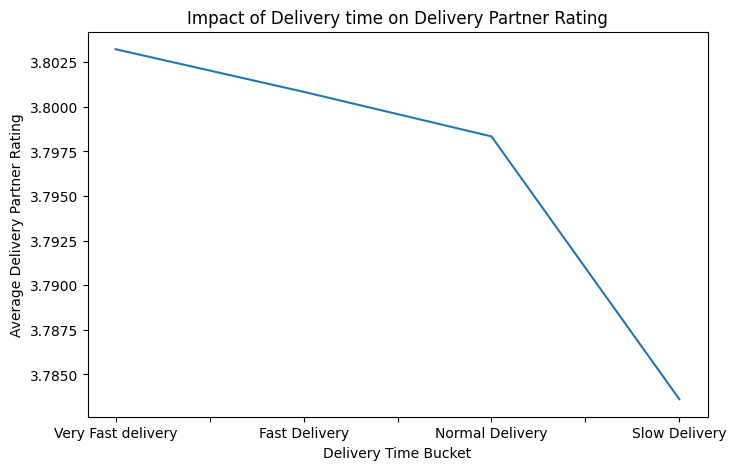

In [ ]:
plt.figure(figsize=(8,5))
bucket_avg.plot()

plt.xlabel('Delivery Time Bucket')
plt.ylabel('Average Delivery Partner Rating')
plt.title('Impact of Delivery time on Delivery Partner Rating')

In [ ]:
#Most popular product category on  Swiggy Instamart, for the people of age between 30-40 in Mumbai
df_pc = df[
    (df['Company'] == 'Swiggy Instamart') &
    ((df['Customer_Age'] >= 30) & (df['Customer_Age'] <= 40)) &
    (df['City'] == 'Mumbai')
  ]

In [ ]:
#Most popular product
df_pc['Product_Category'].value_counts()

,count
Product_Category,
Dairy,408
Groceries,385
Fruits & Vegetables,375
Snacks,374
Household,373
Personal Care,344
Beverages,332


In [ ]:
#Cities that these company should expand into based on performance
city_perf = df.groupby(['Company','City']).agg(
          Total_Order = ('Order_ID','count'),
          Avg_rating = ('Customer_Rating','mean'),
          Avg_delivery_time = ('Delivery_Time_Min','mean'),
          Total_revenue = ('Order_Value','sum')
          ).reset_index()


In [ ]:
city_perf

,Company,City,Total_Order,Avg_rating,Avg_delivery_time,Total_revenue
0,Amazon Now,Amritsar,9934,2.896416,18.167002,5496732
1,Amazon Now,Bengluru,9907,3.387807,19.183406,5645396
2,Amazon Now,Chennai,9848,2.904041,18.138201,5367387
3,Amazon Now,Delhi,9921,2.990223,8.295837,5899927
4,Amazon Now,Gurgaon,9797,2.921711,18.166173,6680388
...,...,...,...,...,...,...
91,Zepto,Jaipur,9680,3.111880,13.144835,4631131
92,Zepto,Kolkata,9829,3.172754,8.303795,5804371
93,Zepto,Mumbai,9864,3.412206,10.152170,6058948
94,Zepto,Noida,10073,3.206592,8.298024,7097628


In [ ]:
best_cities = city_perf[
    (city_perf['Avg_delivery_time'] <= 15) &
    (city_perf['Avg_rating'] >= 3.5) &
    (city_perf['Total_Order']>city_perf['Total_Order'].median())
]

In [ ]:
best_cities

,Company,City,Total_Order,Avg_rating,Avg_delivery_time,Total_revenue
24,Blinkit,Amritsar,9935,3.589129,14.199396,6014261
26,Blinkit,Chennai,9880,3.580668,14.136235,5939770
28,Blinkit,Gurgaon,10080,3.579563,14.199405,7380255
32,Blinkit,Kolkata,10006,3.566760,14.142415,6012506
35,Blinkit,Pune,9909,3.583207,14.163992,5934301
85,Zepto,Bengluru,9974,3.598456,9.199418,6054144


In [ ]:
best_cities[['Company','City']]

,Company,City
24,Blinkit,Amritsar
26,Blinkit,Chennai
28,Blinkit,Gurgaon
32,Blinkit,Kolkata
35,Blinkit,Pune
85,Zepto,Bengluru


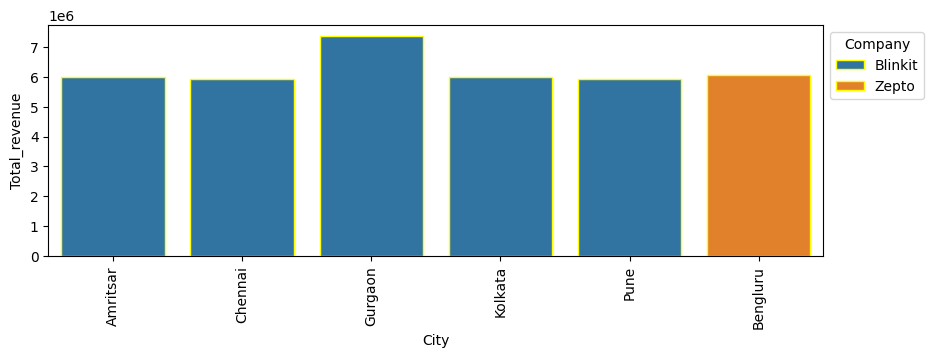

In [ ]:
plt.figure(figsize=(10,3))
sns.barplot(data = best_cities, x = 'City', y = 'Total_revenue', hue = 'Company',edgecolor = 'yellow')
plt.xticks(rotation=90)
plt.legend(title='Company',bbox_to_anchor = (1,1))

In [ ]:
#Are discounts increasing order volume or just reducing revenue

In [ ]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,delivery_time_bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12,12.0,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,13,10.0,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,5,19.0,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6,2.0,Dairy,Credit Card,5,1,5,Very Fast delivery
4,1000005,Dunzo,Mumbai,44,586,12,2,13.0,Household,Wallet,4,0,5,Fast Delivery


In [ ]:
#counting number of orders with and without discounts
df['Discount_Applied'].value_counts()

,count
Discount_Applied,
0,568017
1,379983


In [ ]:
#calculate average order value
dis_order_value = df.groupby('Discount_Applied')['Order_Value'].mean()
dis_order_value

,Order_Value
Discount_Applied,
0,477.230208
1,713.855420


In [ ]:
#calculate sum of items count
dis_items_count = df.groupby('Discount_Applied')['Items_Count'].sum()
dis_items_count

,Items_Count
Discount_Applied,
0,5855463.0
1,3921578.0


In [ ]:
x = df['Discount_Applied'].unique()
x

array([1, 0])

Text(0.5, 1.0, 'Average Items Count')

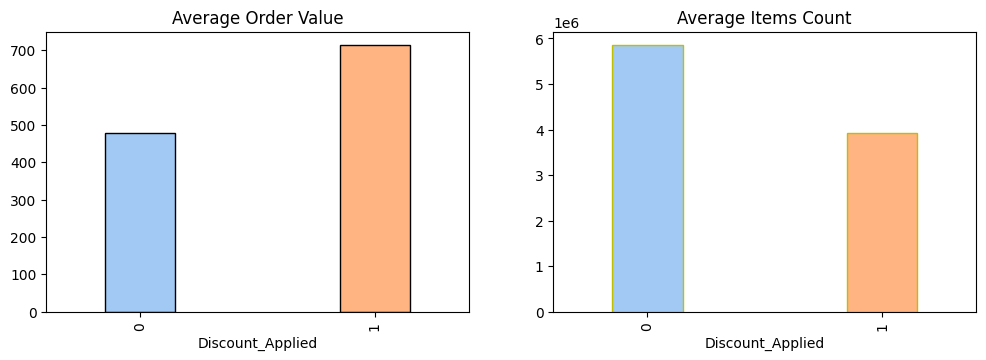

In [ ]:
plt.figure(figsize=(12,8))
colors = sns.color_palette('pastel',len(x))

plt.subplot(2,2,1)
dis_order_value.plot(kind = 'bar', width = 0.3, edgecolor = 'black',color = colors)
plt.title('Average Order Value')


plt.subplot(2,2,2)
dis_items_count.plot(kind = 'bar', width = 0.3, edgecolor = 'y',color = colors)
plt.title('Average Items Count')

In [ ]:
#Which company has the best operational efficiency(Delivery Time vs Order Volume)

In [ ]:
company_efficiency = df.groupby('Company').agg(
    Avg_delivery_time = ('Delivery_Time_Min','mean'),
    Avg_order_value = ('Order_Value','mean'),
    Total_orders = ('Order_ID','count')
).reset_index()
company_efficiency

,Company,Avg_delivery_time,Avg_order_value,Total_orders
0,Amazon Now,18.984048,558.354365,118107
1,Big Basket,18.027345,576.503739,118083
2,Blinkit,15.121381,611.053884,118923
3,Dunzo,14.177461,541.257461,118488
4,Flipkart Minutes,17.045038,564.198010,118989
5,Jio Mart,23.013155,483.715385,118286
6,Swiggy Instamart,16.072677,646.532335,118525
7,Zepto,9.644356,594.656869,118599


In [ ]:
#Normalizing values for fair comparison

from sklearn.preprocessing import MinMaxScaler
#scaling both columns to the range(0,1) so that they can be fairly compared and combined
scaler = MinMaxScaler()
company_efficiency[['Total_orders_Scaled','Avg_delivery_time_Scaled']] = scaler.fit_transform(company_efficiency[['Total_orders','Avg_delivery_time']])


In [ ]:
company_efficiency

,Company,Avg_delivery_time,Avg_order_value,Total_orders,Total_orders_Scaled,Avg_delivery_time_Scaled
0,Amazon Now,18.984048,558.354365,118107,0.026490,0.698619
1,Big Basket,18.027345,576.503739,118083,0.000000,0.627056
2,Blinkit,15.121381,611.053884,118923,0.927152,0.409687
3,Dunzo,14.177461,541.257461,118488,0.447020,0.339081
4,Flipkart Minutes,17.045038,564.198010,118989,1.000000,0.553579
5,Jio Mart,23.013155,483.715385,118286,0.224062,1.000000
6,Swiggy Instamart,16.072677,646.532335,118525,0.487859,0.480845
7,Zepto,9.644356,594.656869,118599,0.569536,0.000000


In [ ]:
#Calculating efficiency score
company_efficiency['Efficiency_Score'] = (company_efficiency['Total_orders_Scaled'] - company_efficiency['Avg_delivery_time_Scaled'])
company_efficiency

,Company,Avg_delivery_time,Avg_order_value,Total_orders,Total_orders_Scaled,Avg_delivery_time_Scaled,Efficiency_Score
0,Amazon Now,18.984048,558.354365,118107,0.026490,0.698619,-0.672129
1,Big Basket,18.027345,576.503739,118083,0.000000,0.627056,-0.627056
2,Blinkit,15.121381,611.053884,118923,0.927152,0.409687,0.517465
3,Dunzo,14.177461,541.257461,118488,0.447020,0.339081,0.107939
4,Flipkart Minutes,17.045038,564.198010,118989,1.000000,0.553579,0.446421
5,Jio Mart,23.013155,483.715385,118286,0.224062,1.000000,-0.775938
6,Swiggy Instamart,16.072677,646.532335,118525,0.487859,0.480845,0.007014
7,Zepto,9.644356,594.656869,118599,0.569536,0.000000,0.569536


In [ ]:
#sort by best efficiency
eff = company_efficiency.sort_values(by = 'Efficiency_Score' , ascending=False)

In [ ]:
eff # it means zepto has the best operational efficiency

,Company,Avg_delivery_time,Avg_order_value,Total_orders,Total_orders_Scaled,Avg_delivery_time_Scaled,Efficiency_Score
7,Zepto,9.644356,594.656869,118599,0.569536,0.000000,0.569536
2,Blinkit,15.121381,611.053884,118923,0.927152,0.409687,0.517465
4,Flipkart Minutes,17.045038,564.198010,118989,1.000000,0.553579,0.446421
3,Dunzo,14.177461,541.257461,118488,0.447020,0.339081,0.107939
6,Swiggy Instamart,16.072677,646.532335,118525,0.487859,0.480845,0.007014
1,Big Basket,18.027345,576.503739,118083,0.000000,0.627056,-0.627056
0,Amazon Now,18.984048,558.354365,118107,0.026490,0.698619,-0.672129
5,Jio Mart,23.013155,483.715385,118286,0.224062,1.000000,-0.775938


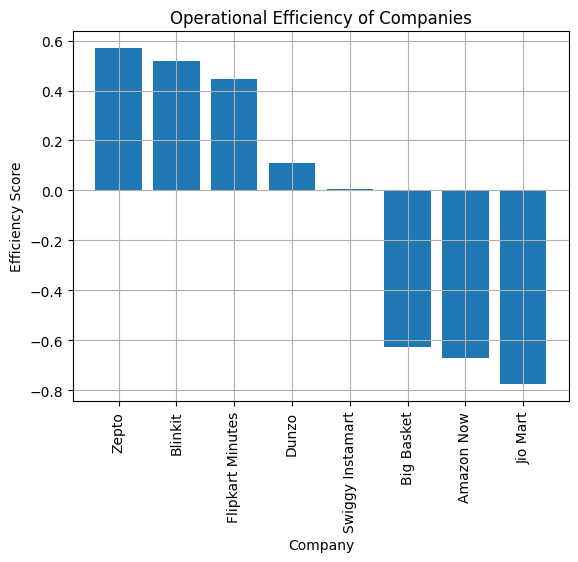

In [ ]:
plt.bar(eff['Company'],eff['Efficiency_Score'])
plt.xlabel('Company')
plt.ylabel('Efficiency Score')
plt.title('Operational Efficiency of Companies')
plt.xticks(rotation=90)
plt.grid(True)

In [ ]:
from re import template
import plotly.express as px

min_eff = eff['Efficiency_Score'].min()
eff['Bubble_Size'] = eff['Efficiency_Score'] - min_eff + 0.1

fig = px.scatter(eff, x='Total_orders', y='Avg_delivery_time', size='Bubble_Size', color = 'Company' , text = 'Company',
                 title='Operational Efficiency of Companies',
                 hover_data={'Total_orders':True,'Avg_delivery_time':':.2f' , 'Efficiency_Score':':.3f'}, size_max=40)
fig.update_traces(textposition='middle center')
fig.update_layout(
    xaxis_title='Total Orders(Higher is better)',
    yaxis_title='Average Delivery Time (Lower is better)',
    template='plotly_dark',
    height=600,
    width=800
)
fig.show()


# **MINI** **DASHBOARD**

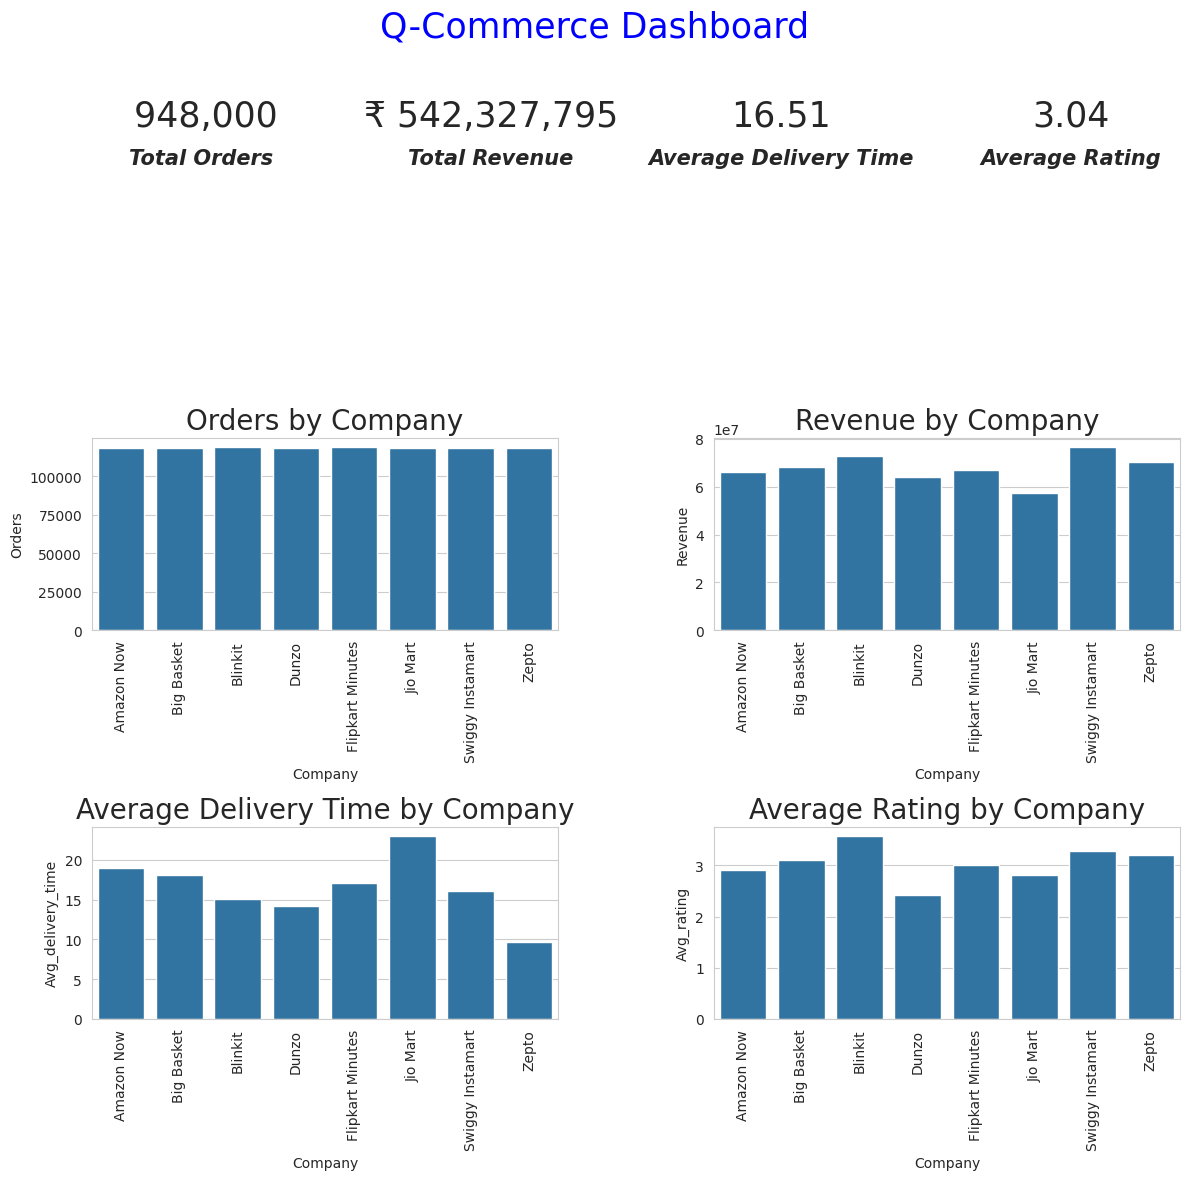

In [ ]:
fig = plt.figure(figsize=(12,12))
sns.set_style('whitegrid')

#--KPI CALCULATIONS --
total_orders = df['Order_ID'].count()
total_revenue = df['Order_Value'].sum()
avg_delivery_time = df['Delivery_Time_Min'].mean()
avg_rating = df['Customer_Rating'].mean()

#--KPI CARDS--
plt.subplot2grid((3,4),(0,0))
plt.axis('off')
plt.text(0.5,0.6, f"{total_orders: ,}",fontsize = 25, ha = 'center')
plt.text(0.5,0.4,"Total Orders",fontsize = 15 , ha='center' , fontstyle = 'italic',fontweight = 'bold')

plt.subplot2grid((3,4),(0,1))
plt.axis('off')
plt.text(0.5,0.6, f"₹{total_revenue: ,}",fontsize = 25, ha = 'center')
plt.text(0.5,0.4,"Total Revenue",fontsize = 15 , ha='center' , fontstyle = 'italic',fontweight = 'bold')

plt.subplot2grid((3,4),(0,2))
plt.axis('off')
plt.text(0.5,0.6, f"{avg_delivery_time:.2f}",fontsize = 25, ha = 'center')
plt.text(0.5,0.4,"Average Delivery Time",fontsize = 15 , ha='center' , fontstyle = 'italic',fontweight = 'bold')

plt.subplot2grid((3,4),(0,3))
plt.axis('off')
plt.text(0.5,0.6, f"{avg_rating:.2f}",fontsize = 25, ha = 'center')
plt.text(0.5,0.4,"Average Rating",fontsize = 15 , ha='center' , fontstyle = 'italic',fontweight = 'bold')


#--COMPANY LEVEL METRICS--
company_metrics = df.groupby('Company').agg(
    Orders = ('Order_ID','count'),
    Revenue = ('Order_Value','sum'),
    Avg_delivery_time = ('Delivery_Time_Min','mean'),
    Avg_rating = ('Customer_Rating','mean')
).reset_index()

#-- CHARTS SECTION --
plt.subplot2grid((3,2),(1,0))
sns.barplot(data=company_metrics, x = 'Company' , y= 'Orders')
plt.xticks(rotation=90)
plt.title('Orders by Company',fontsize = 20)

plt.subplot2grid((3,2),(1,1))
sns.barplot(data=company_metrics, x = 'Company' , y= 'Revenue')
plt.xticks(rotation=90)
plt.title('Revenue by Company',fontsize=20)

plt.subplot2grid((3,2),(2,0))
sns.barplot(data=company_metrics, x = 'Company' , y= 'Avg_delivery_time')
plt.xticks(rotation=90)
plt.title('Average Delivery Time by Company', fontsize = 20)

plt.subplot2grid((3,2),(2,1))
sns.barplot(data=company_metrics, x = 'Company' , y= 'Avg_rating')
plt.xticks(rotation=90)
plt.title('Average Rating by Company', fontsize = 20)

#title
plt.suptitle('Q-Commerce Dashboard', fontsize = 25, color = 'blue')
plt.tight_layout()
plt.show()